In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\Ali\Downloads\Credit Card Customer Churn Prediction\Churn_Modelling.csv")


In [4]:
print(df.head())
df.shape


   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

(10000, 14)

In [5]:
df.drop(columns = ['RowNumber', 'CustomerId', 'Surname'],inplace = True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [7]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [9]:
df = pd.get_dummies(df, columns = ['Geography', 'Gender'], drop_first = True, dtype = int )

In [10]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [11]:
X = df.drop(columns = ['Exited'])
y = df['Exited']

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [14]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [16]:
model = Sequential()
model.add(Dense(11, activation = 'relu',input_dim = 11))
model.add(Dense(11, activation ='relu'))
model.add(Dense(1, activation = 'sigmoid'))

c:\Users\Ali\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [19]:
history = model.fit(X_train_scaled, y_train,epochs =100, validation_split = 0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.7923 - loss: 0.5148 - val_accuracy: 0.7987 - val_loss: 0.4651
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7953 - loss: 0.4578 - val_accuracy: 0.8112 - val_loss: 0.4298
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8133 - loss: 0.4335 - val_accuracy: 0.8294 - val_loss: 0.4118
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8253 - loss: 0.4194 - val_accuracy: 0.8350 - val_loss: 0.4008
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8308 - loss: 0.4087 - val_accuracy: 0.8375 - val_loss: 0.3916
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8366 - loss: 0.3970 - val_accuracy: 0.8438 - val_loss: 0.3820
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8436 - loss: 0.3854 - val_accuracy: 0.8469 - val_loss: 0.3724
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8508 - loss: 0.3730 -

In [20]:
model.layers[0].get_weights()

[array([[-0.18482386, -0.04533404, -0.0304921 , -0.18769681, -0.1316163 ,
          0.13055691,  0.15395398,  0.03542895, -0.09357864, -0.07078543,
         -0.18390605],
        [-0.57631856, -0.6358397 ,  1.2179196 ,  0.14469606,  0.44039065,
         -0.19089267, -0.70997065, -0.96458554,  0.21020688,  0.43605506,
          0.15945502],
        [ 0.19904688, -0.20298602, -0.07459852, -0.5177703 ,  0.02384831,
          0.05313639, -0.46413174, -0.14284885,  0.00265806,  0.32098687,
          0.33550987],
        [ 0.46483436, -0.45453718,  0.07251549,  0.01577132,  0.06827365,
         -0.44296923, -0.6047733 ,  0.1204973 ,  0.23482169, -0.47597685,
         -0.48306105],
        [-0.06171364,  0.58842796, -0.19064467, -0.9477756 ,  0.06091408,
          0.12570322,  0.3116091 , -0.28508124,  1.2122593 , -1.11622   ,
          0.05909412],
        [ 0.11092169,  0.28158456,  0.1414422 ,  0.02446897,  0.21670529,
         -0.14491381, -0.07627028,  0.02228856, -0.03706474, -0.0806106

In [21]:
model.layers[1].get_weights()

[array([[ 4.6729964e-01, -3.8622192e-01,  3.3253747e-01, -6.0708463e-01,
          1.8083613e-03,  4.9113059e-01,  3.6361888e-01, -2.8408751e-01,
         -4.7425431e-01,  4.9245086e-01, -5.0706166e-01],
        [ 1.7034810e-02, -2.3705266e-01, -1.6748083e-01,  7.5885201e-01,
          2.7362970e-01,  1.6242862e-01, -1.7158140e-01,  4.9320021e-01,
          2.4517238e-01,  2.4683152e-01,  3.6250431e-02],
        [ 6.1067384e-01, -1.3207890e-01,  3.9561695e-01,  5.2391356e-01,
         -3.3034053e-02, -8.6844015e-01, -8.6115056e-01,  7.3968017e-01,
         -3.0985719e-01,  5.4083550e-01, -6.4960158e-01],
        [ 3.2638326e-01, -1.5746516e-01, -6.6348034e-01, -3.7154341e-01,
         -4.7421786e-01, -1.7629167e-01,  2.1380693e-02, -1.8653801e-01,
          5.7441294e-01,  4.5470458e-02,  2.3637377e-01],
        [-3.7668914e-01, -3.6449942e-01, -1.2881018e+00,  4.0549532e-01,
         -3.3844137e-01,  2.3555435e-01, -1.2530148e-01,  2.0456648e-01,
         -2.8903434e-01, -4.1863787e-0

In [22]:
model.layers[2].get_weights()

[array([[ 0.7645842 ],
        [ 0.16133355],
        [ 0.8632291 ],
        [-0.85287845],
        [-0.24393979],
        [-1.0021222 ],
        [-1.101198  ],
        [-0.73284256],
        [ 0.9125856 ],
        [-0.29254833],
        [-0.6745313 ]], dtype=float32),
 array([0.13607128], dtype=float32)]

In [23]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step


In [24]:
y_pred = np.where(y_log > 0.5, 1, 0)

In [25]:
from sklearn.metrics import accuracy_score
score= accuracy_score(y_test, y_pred)

In [26]:
print(score)

0.8585


In [27]:
history.history

{'accuracy': [0.7923437356948853,
  0.7953125238418579,
  0.813281238079071,
  0.8253124952316284,
  0.8307812213897705,
  0.8365625143051147,
  0.8435937762260437,
  0.850781261920929,
  0.8520312309265137,
  0.8568750023841858,
  0.858593761920929,
  0.8568750023841858,
  0.8579687476158142,
  0.8584374785423279,
  0.859375,
  0.859375,
  0.8600000143051147,
  0.8592187762260437,
  0.8600000143051147,
  0.8614062666893005,
  0.8607812523841858,
  0.8618749976158142,
  0.8623437285423279,
  0.8612499833106995,
  0.8620312213897705,
  0.8635937571525574,
  0.8629687428474426,
  0.8635937571525574,
  0.86328125,
  0.8646875023841858,
  0.864062488079071,
  0.864062488079071,
  0.8631250262260437,
  0.864062488079071,
  0.8628125190734863,
  0.8650000095367432,
  0.8631250262260437,
  0.8642187714576721,
  0.8653125166893005,
  0.8662499785423279,
  0.8639062643051147,
  0.864062488079071,
  0.8656250238418579,
  0.8665624856948853,
  0.8609374761581421,
  0.8657812476158142,
  0.8659374

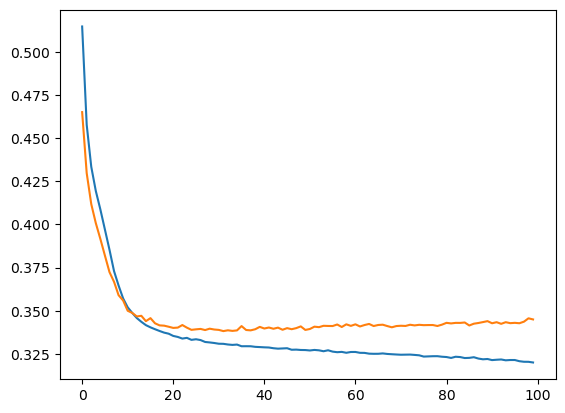

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

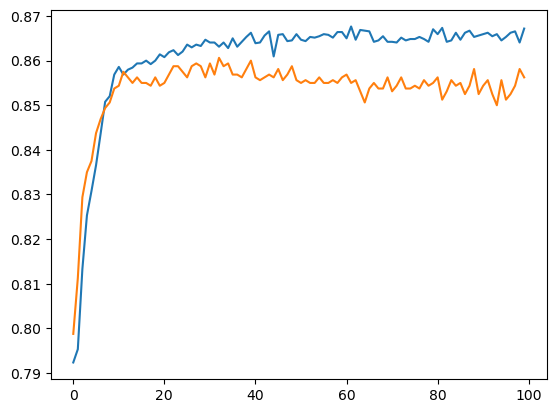

In [29]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])